1. PENDAHULUAN

  Tujuan: Membangun model machine learning untuk memprediksi kemungkinan churn (berhenti berlangganan) pelanggan e-commerce berdasarkan data historis mereka.



2. IMPORT DAN SETUP AWAL

In [ ]:
# =========================
# IMPORT LIBRARY
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visualisasi setup
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, auc
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier

# Handling imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline



Import library yang dibutuhkan: pandas (manipulasi data), numpy (komputasi numerik), matplotlib/seaborn (visualisasi), scikit-learn (machine learning), XGBoost (model boosting), imbalanced-learn (handle data tidak seimbang).

3. DATA COLLECTION dan PERSIAPAN

In [ ]:
# =========================
# LOAD DATA
# =========================
df = pd.read_csv('E Commerce Dataset.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\n" + "="*50)

Shape: (5630, 20)
Columns: ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']



2. LOADING DATA
Maksud: Memasukkan dataset ke dalam memori untuk dianalisis.

Membaca file CSV menggunakan pandas.

Mengecek struktur data: jumlah baris (3336) dan kolom (20).

Output: DataFrame siap untuk dieksplorasi.

Data Colecction dimulai dengan membaca file 'E Commerce Dataset.csv' menggunakan pandas, yang berhasil mengimpor dataset berisi 3.336 baris data pelanggan dengan 20 kolom informasi yang mencakup berbagai aspek.

4. EKSPLORASI DATA (EDA)


4.1 Informasi Dasar Dataset

In [ ]:
print("=== INFO DATASET ===")
df.info()

print("\n=== SAMPLE DATA ===")
display(df.head())

print("\n=== STATISTIK DESKRIPTIF ===")
display(df.describe().T)

print("\n=== STATISTIK KATEGORIKAL ===")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 1

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60



=== STATISTIK DESKRIPTIF ===


,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.50,54222.7500,55630.00
Churn,5630.0,0.168384,0.374240,0.0,0.00,0.00,0.0000,1.00
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.00,16.0000,61.00
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.00,3.0000,3.00
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.00,20.0000,127.00
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.00,3.0000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.00
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.00,4.0000,5.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.00
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.00,1.0000,1.00



=== STATISTIK KATEGORIKAL ===

PreferredLoginDevice:
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

PreferredPaymentMode:
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Gender:
Gender
Male      3384
Female    2246
Name: count, dtype: int64

PreferedOrderCat:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus:
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


df.info(): Melihat tipe data dan non-null counts.

df.describe(): Statistik deskriptif (mean, std, min, max) untuk numerik.

Fungsi: Mendeteksi masalah awal seperti tipe data yang salah

4.2 Analisis Missing Values

=== MISSING VALUES ANALYSIS ===


,Missing_Count,Missing_Percentage
Tenure,264,4.689165
WarehouseToHome,251,4.458259
HourSpendOnApp,255,4.529307
OrderAmountHikeFromlastYear,265,4.706927
CouponUsed,256,4.547069
OrderCount,258,4.582593
DaySinceLastOrder,307,5.452931


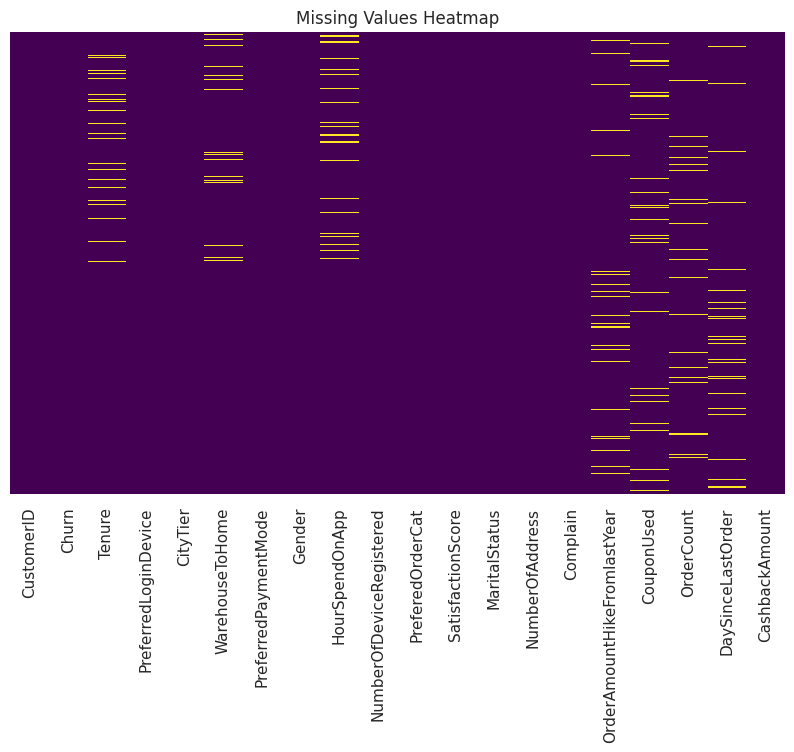

In [ ]:
print("=== MISSING VALUES ANALYSIS ===")
missing_df = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_df = missing_df[missing_df['Missing_Count'] > 0]
display(missing_df)

# Visualisasi missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

Identifikasi kolom yang memiliki data hilang.

Visualisasi heatmap untuk melihat pola missing values.

Fungsi: Memutuskan strategi imputasi nantinya.

4.3 Distribusi Target (Churn)

=== DISTRIBUSI TARGET CHURN ===
Jumlah Tidak Churn (0): 4682 (83.16%)
Jumlah Churn (1): 948 (16.84%)


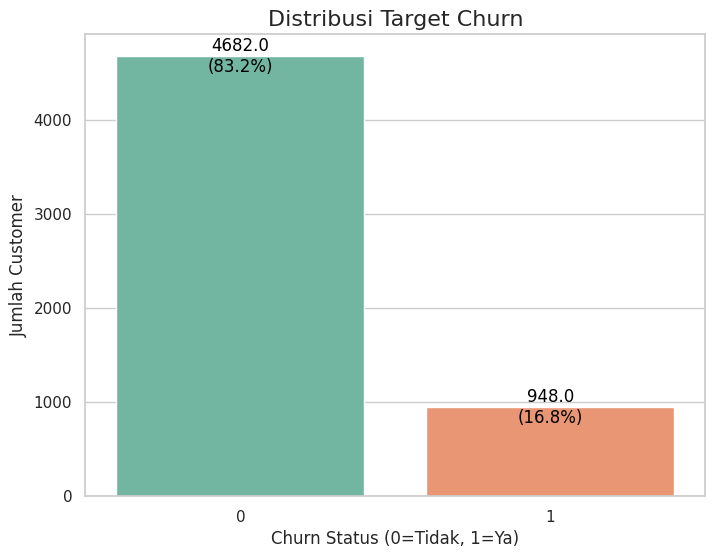

In [ ]:
print("=== DISTRIBUSI TARGET CHURN ===")
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

print(f"Jumlah Tidak Churn (0): {churn_counts[0]} ({churn_percent[0]:.2f}%)")
print(f"Jumlah Churn (1): {churn_counts[1]} ({churn_percent[1]:.2f}%)")

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribusi Target Churn', fontsize=16)
plt.xlabel('Churn Status (0=Tidak, 1=Ya)')
plt.ylabel('Jumlah Customer')

# Tambah label jumlah
for p in ax.patches:
    ax.annotate(f'{p.get_height()}\n({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black')

plt.show()

Analisis class imbalance (perbandingan churn vs non-churn).

Visualisasi distribusi target.

Fungsi: Menentukan apakah perlu teknik handling imbalance.

4.4 Analisis Variabel Numerik

=== ANALISIS VARIABEL NUMERIK ===


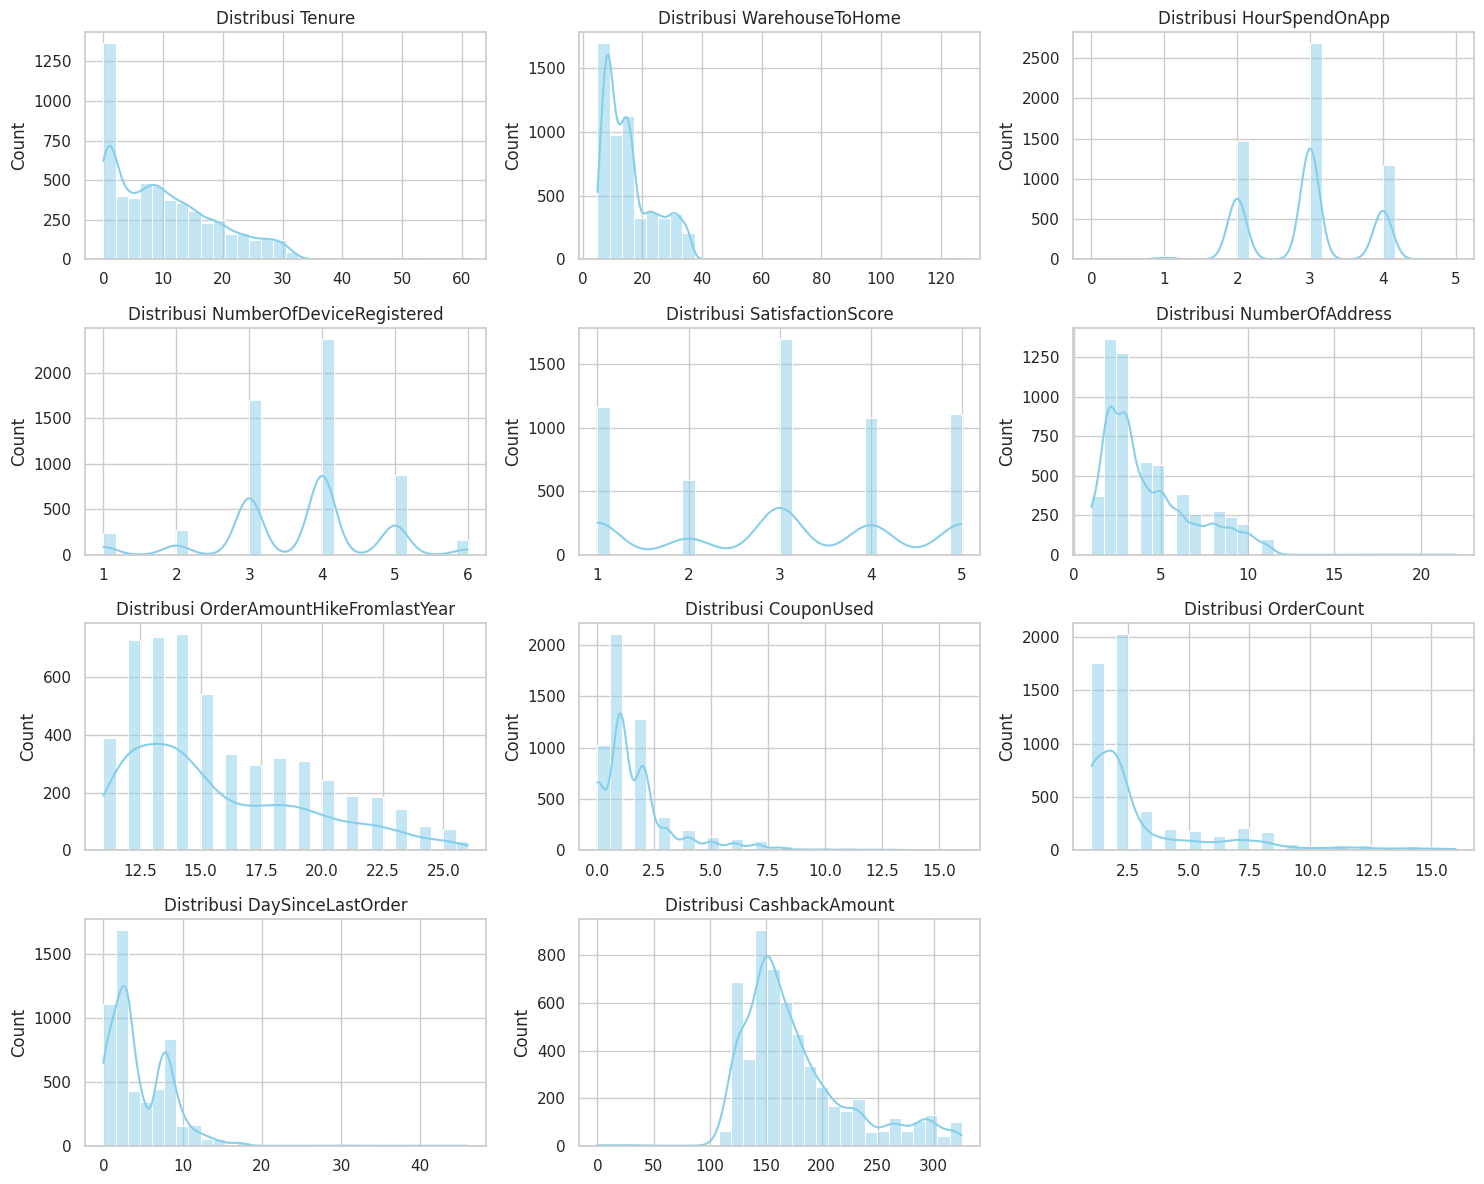

In [ ]:
print("=== ANALISIS VARIABEL NUMERIK ===")
numerical_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                  'NumberOfDeviceRegistered', 'SatisfactionScore',
                  'NumberOfAddress', 'OrderAmountHikeFromlastYear',
                  'CouponUsed', 'OrderCount', 'DaySinceLastOrder',
                  'CashbackAmount']

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, bins=30, ax=ax, color='skyblue')
    ax.set_title(f'Distribusi {col}', fontsize=12)
    ax.set_xlabel('')

# Hide empty subplot
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

Plot distribusi setiap variabel numerik (histogram + KDE).

Fungsi: Memahami sebaran data, mendeteksi outlier, skewness.

Analisis ini mengeksplorasi distribusi 11 variabel numerik utama melalui histogram dengan KDE (Kernel Density Estimate), yang mengungkapkan karakteristik seperti sebaran data, skewness (kemiringan), dan potensi outlier untuk setiap fitur. Visualisasi dalam grid 4×3 memungkinkan perbandingan cepat antar variabel, membantu mengidentifikasi fitur dengan distribusi normal, right-skewed, atau left-skewed yang nantinya akan menentukan kebutuhan transformasi data seperti scaling atau normalisasi sebelum pemodelan.


4.5 Analisis Variabel Kategorikal

=== ANALISIS VARIABEL KATEGORIKAL ===


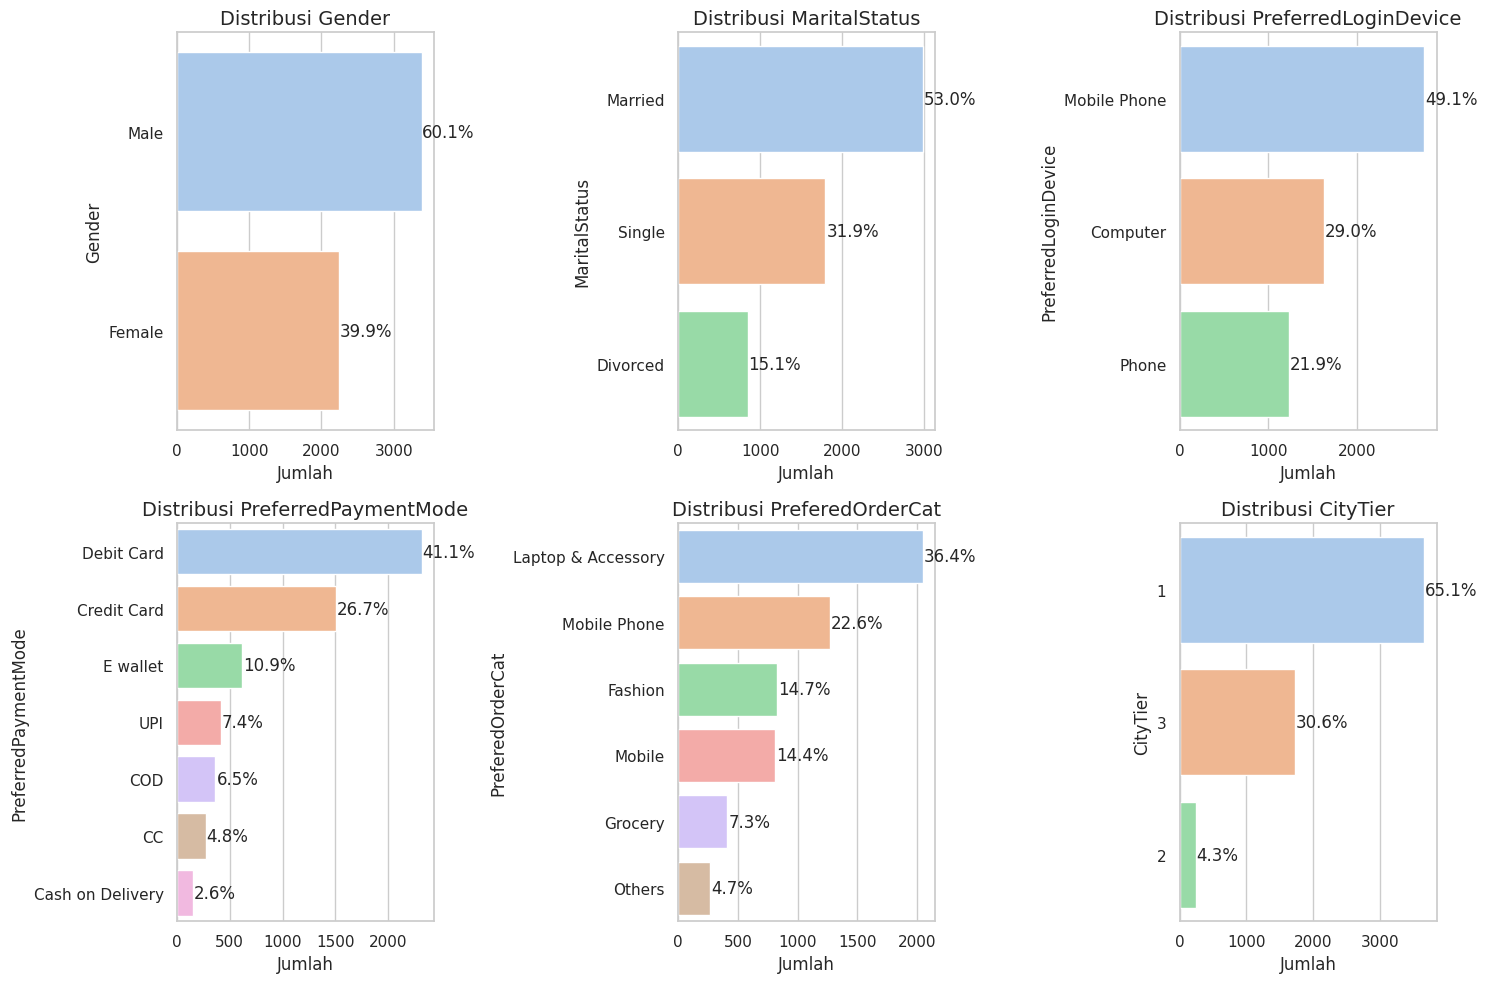

In [ ]:
print("=== ANALISIS VARIABEL KATEGORIKAL ===")
categorical_features = ['Gender', 'MaritalStatus', 'PreferredLoginDevice',
                        'PreferredPaymentMode', 'PreferedOrderCat', 'CityTier']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    ax = axes[i]
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, ax=ax, palette='pastel', order=order)
    ax.set_title(f'Distribusi {col}', fontsize=14)
    ax.set_xlabel('Jumlah')

    # Tambah persentase
    total = len(df[col])
    for p in ax.patches:
        percentage = f'{100 * p.get_width()/total:.1f}%'
        ax.text(p.get_width() + 10, p.get_y() + p.get_height()/2,
                percentage, ha='left', va='center')

plt.tight_layout()
plt.show()

Plot distribusi setiap variabel kategorikal.

Fungsi: Memahami proporsi kategori, identifikasi kategori dominan.

Analisis ini mengevaluasi distribusi 6 variabel kategorikal melalui countplot horizontal dengan label persentase, mengungkapkan proporsi setiap kategori seperti distribusi gender, status pernikahan, preferensi perangkat login, metode pembayaran favorit, kategori produk pilihan, dan tier kota. Visualisasi dalam grid 2×3 memungkinkan identifikasi kategori dominan dan ketidakseimbangan dalam data kategorikal, yang penting untuk menentukan strategi encoding (seperti one-hot encoding) dan memahami representasi berbagai segmen pelanggan dalam dataset sebelum pemodelan.


4.6 Korelasi antar Variabel

=== MATRIKS KORELASI ===


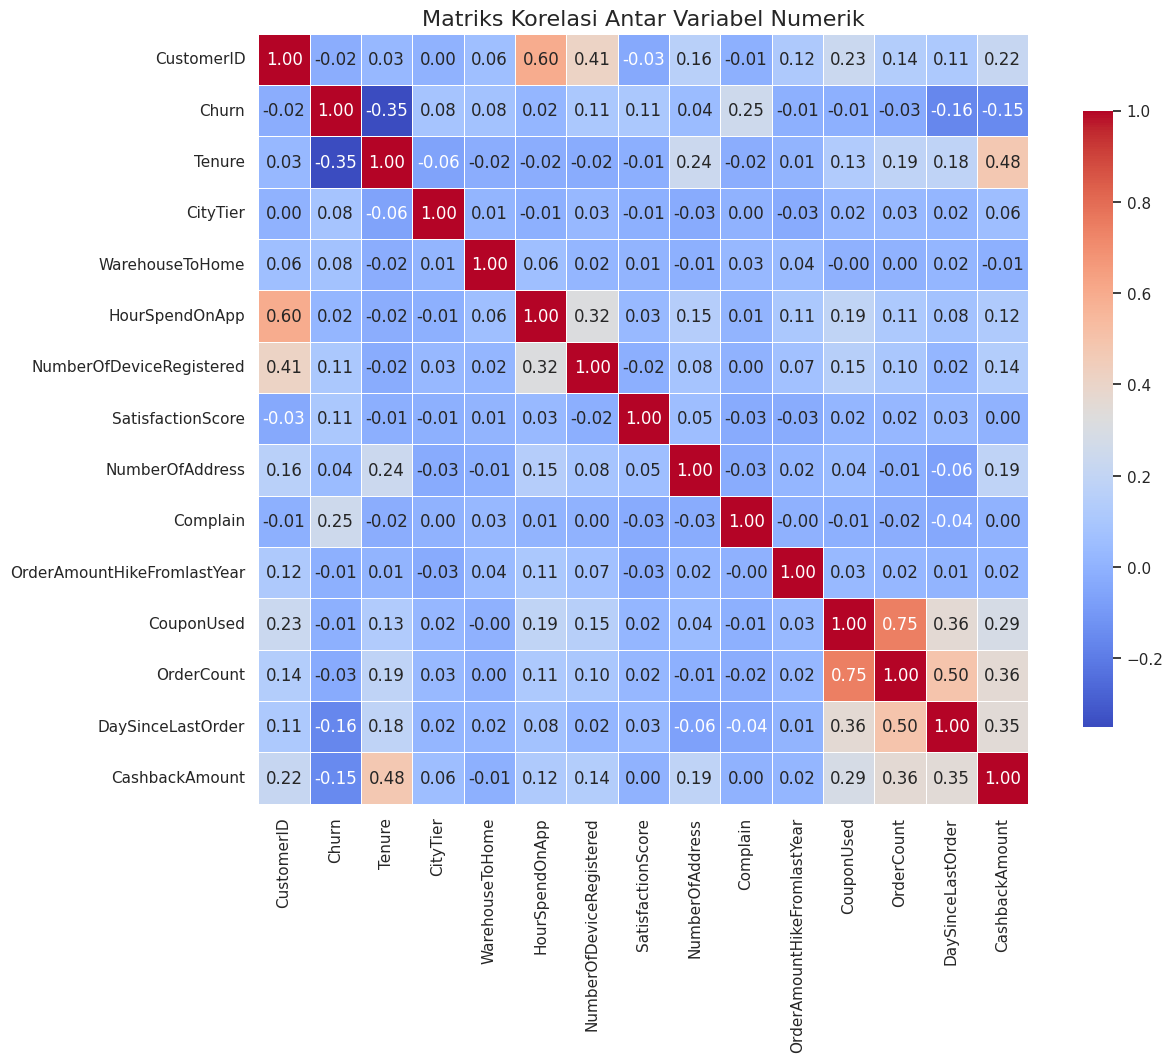


=== KORELASI DENGAN TARGET ===


,Churn
Churn,1.000000
Complain,0.250188
NumberOfDeviceRegistered,0.107939
SatisfactionScore,0.105481
CityTier,0.084703
WarehouseToHome,0.076630
NumberOfAddress,0.043931
HourSpendOnApp,0.018675
CouponUsed,-0.008264
OrderAmountHikeFromlastYear,-0.010058


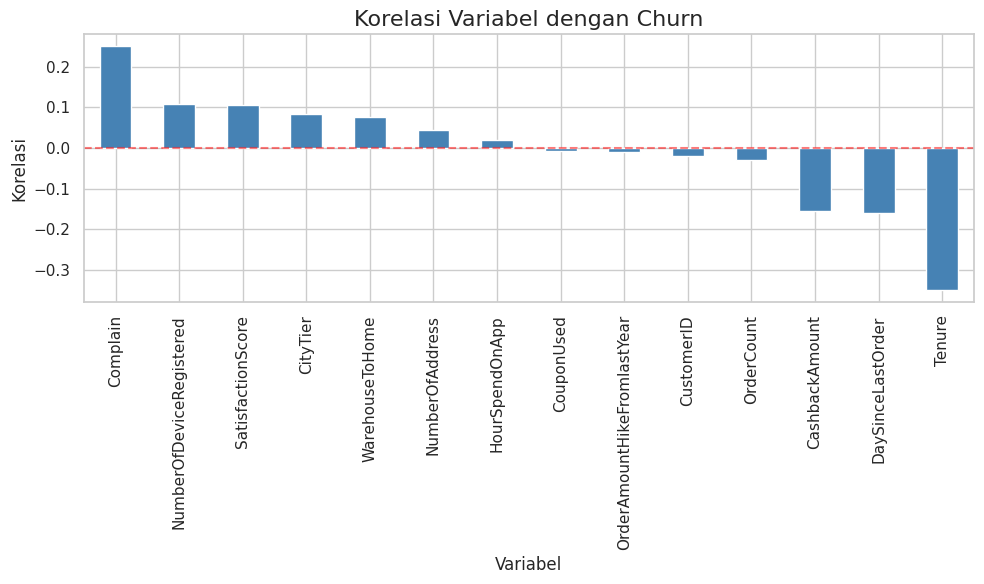

In [ ]:
print("=== MATRIKS KORELASI ===")
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5,
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Matriks Korelasi Antar Variabel Numerik', fontsize=16)
plt.show()

# Korelasi dengan target
print("\n=== KORELASI DENGAN TARGET ===")
correlation_with_target = correlation_matrix['Churn'].sort_values(ascending=False)
display(correlation_with_target)

# Visualisasi korelasi dengan target
plt.figure(figsize=(10, 6))
correlation_with_target.drop('Churn').plot(kind='bar', color='steelblue')
plt.title('Korelasi Variabel dengan Churn', fontsize=16)
plt.xlabel('Variabel')
plt.ylabel('Korelasi')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Matriks korelasi untuk melihat hubungan linear antar variabel.

Fungsi: Mendeteksi multicollinearity, identifikasi variabel yang saling terkait.

Korelasi dengan target: Identifikasi variabel yang paling berkaitan dengan churn.

4.7 Analisis Bivariate (Variabel vs Churn)

=== ANALISIS VARIABEL vs CHURN ===


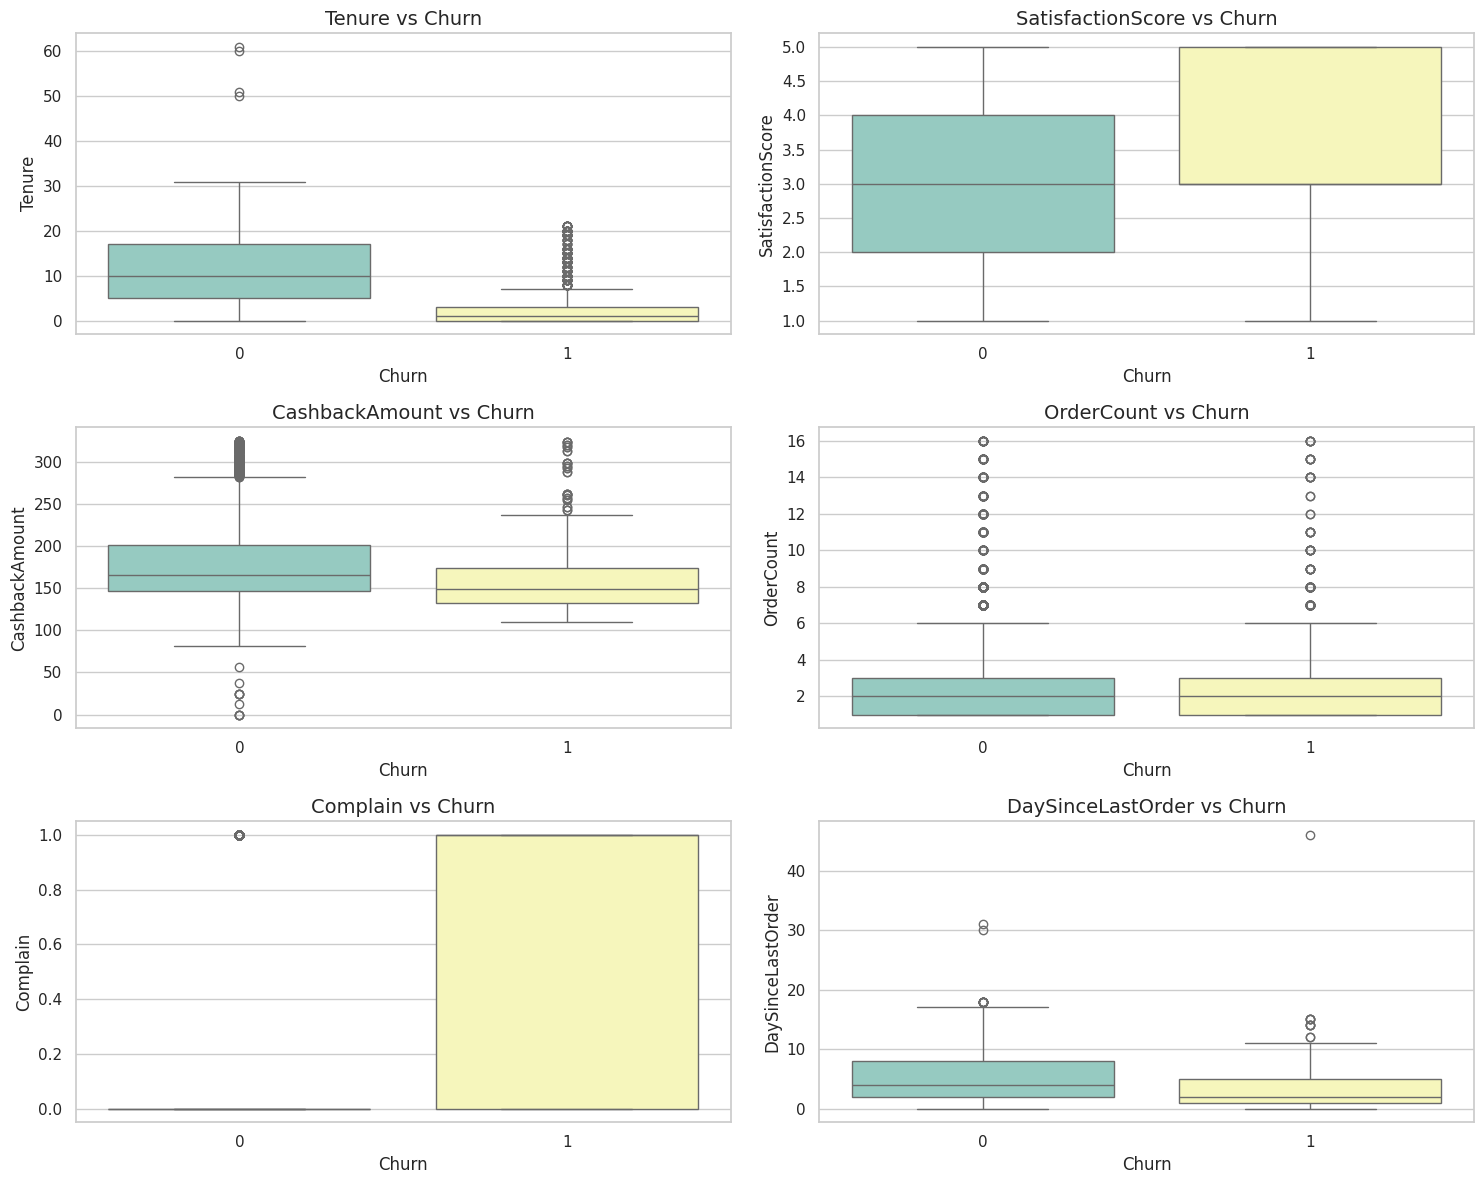


=== ANALISIS KATEGORIKAL vs CHURN ===


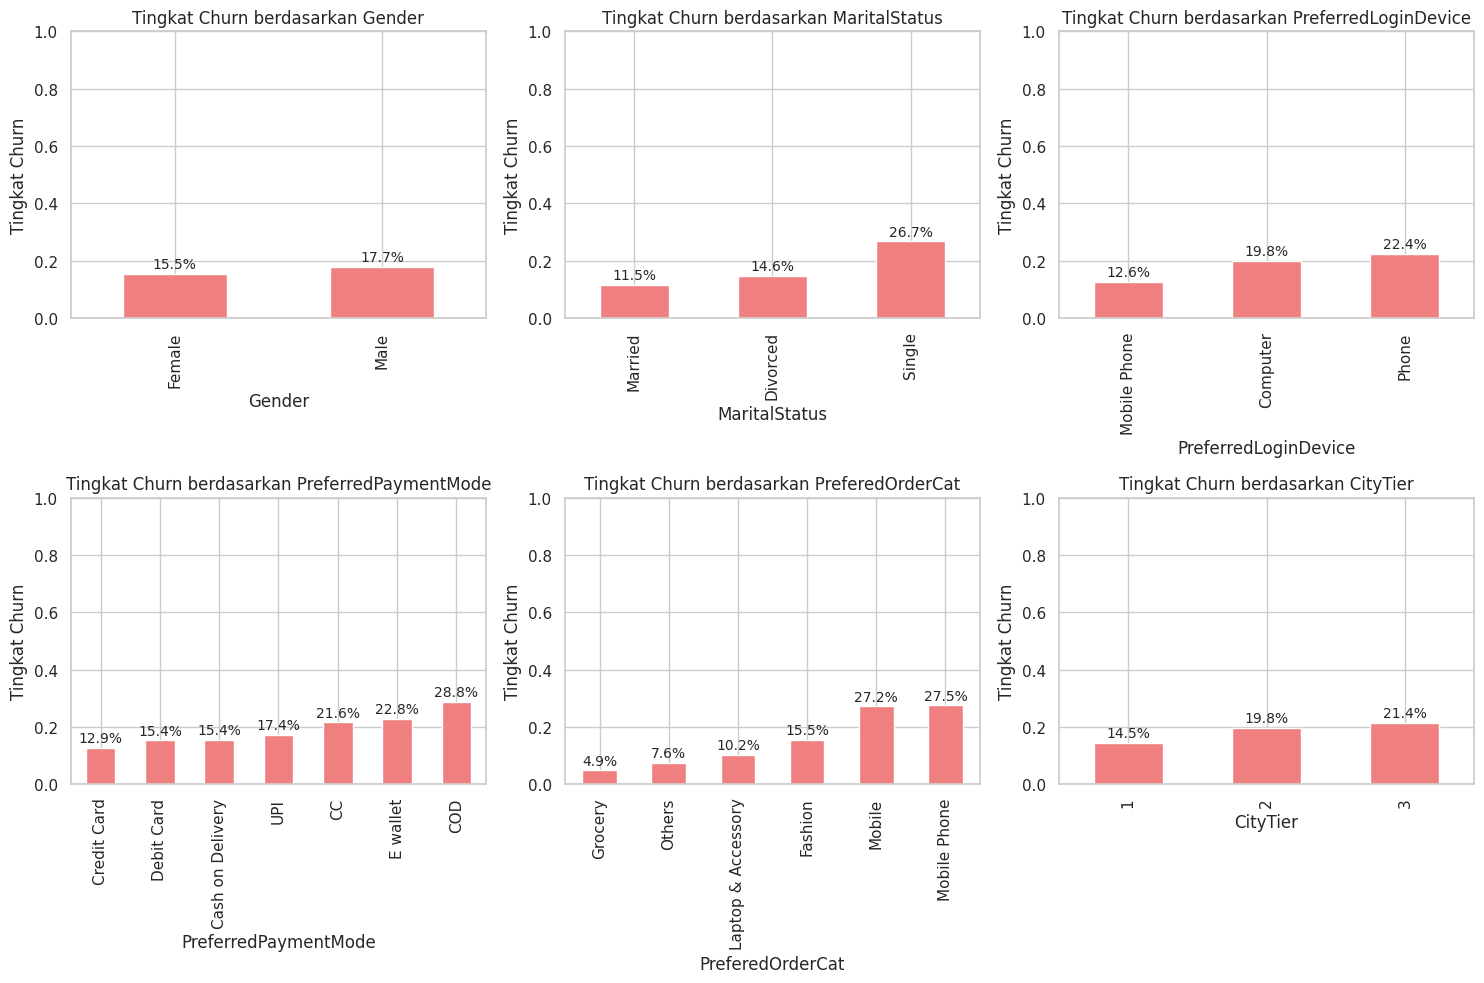

In [ ]:
print("=== ANALISIS VARIABEL vs CHURN ===")
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

# Contoh: analisis beberapa variabel penting
analysis_cols = ['Tenure', 'SatisfactionScore', 'CashbackAmount',
                 'OrderCount', 'Complain', 'DaySinceLastOrder']

for i, col in enumerate(analysis_cols):
    ax = axes[i]
    sns.boxplot(x='Churn', y=col, data=df, ax=ax, palette='Set3')
    ax.set_title(f'{col} vs Churn', fontsize=14)
    ax.set_xlabel('Churn')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

# Analisis kategori vs churn
print("\n=== ANALISIS KATEGORIKAL vs CHURN ===")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(['Gender', 'MaritalStatus', 'PreferredLoginDevice',
                         'PreferredPaymentMode', 'PreferedOrderCat', 'CityTier']):
    ax = axes[i]
    churn_rate = df.groupby(col)['Churn'].mean().sort_values()
    churn_rate.plot(kind='bar', ax=ax, color='lightcoral')
    ax.set_title(f'Tingkat Churn berdasarkan {col}', fontsize=12)
    ax.set_ylabel('Tingkat Churn')
    ax.set_xlabel(col)
    ax.set_ylim([0, 1])

    # Tambah label persentase
    for j, v in enumerate(churn_rate):
        ax.text(j, v + 0.02, f'{v:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Boxplot numerik vs churn: Melihat perbedaan distribusi antara churn dan non-churn.

Churn rate per kategori: Menghitung persentase churn untuk setiap kategori.

Fungsi: Identifikasi pola dan hubungan antara fitur dengan target.

Analisis ini mengeksplorasi hubungan antara variabel numerik dan kategorikal dengan target churn melalui dua pendekatan. Untuk variabel numerik, boxplot membandingkan distribusi antara pelanggan churn dan non-churn, mengungkapkan perbedaan median, sebaran, dan outlier untuk variabel seperti tenure, skor kepuasan, cashback, jumlah pesanan, keluhan, dan hari sejak pesanan terakhir. Untuk variabel kategorikal, bar plot menampilkan tingkat churn per kategori (persentase pelanggan yang churn dalam setiap kelompok), mengidentifikasi kategori dengan risiko churn tertinggi dan terendah berdasarkan gender, status pernikahan, perangkat login, metode pembayaran, kategori produk, dan tier kota. Analisis ini memberikan insight praktis tentang faktor-faktor yang paling mempengaruhi churn dan pola yang dapat dimanfaatkan untuk strategi retensi yang ditargetkan.

Penjelasan var numerik
1. Karakteristik Pelanggan yang Berhenti (Churn 1)
Berdasarkan grafik, pelanggan yang berhenti cenderung memiliki profil berikut:
Tenure (Masa Berlangganan) Rendah: Mayoritas pelanggan yang churn adalah pelanggan baru dengan masa berlangganan yang sangat singkat (mendekati 0). Sebaliknya, pelanggan yang loyal (Tenure tinggi) lebih stabil.
Complain (Keluhan) Tinggi: Grafik menunjukkan bahwa kotak kuning (Churn 1) berada di area nilai 1.0, yang berarti sebagian besar pelanggan yang churn adalah mereka yang pernah melakukan komplain.
CashbackAmount Lebih Rendah: Secara rata-rata, mereka yang berhenti menerima jumlah cashback yang lebih sedikit dibandingkan mereka yang bertahan.
Satisfaction Score Tinggi (Paradoks): Menariknya, box plot menunjukkan skor kepuasan pelanggan yang churn justru sering kali berada di angka tinggi (4-5). Ini bisa menandakan adanya masalah mendadak yang membuat mereka kecewa meski sebelumnya merasa puas, atau data skor ini diambil saat mereka pertama kali bergabung.

2. Karakteristik Pelanggan yang Bertahan (Churn 0)
DaySinceLastOrder Lebih Lama: Pelanggan yang bertahan memiliki sebaran waktu sejak order terakhir yang lebih luas dan cenderung lebih tinggi dibanding mereka yang churn.
Tenure Lebih Stabil: Mereka memiliki rentang masa berlangganan yang lebih panjang dan konsisten.
3. Variabel yang Tidak Terlalu Berpengaruh
OrderCount: Jika Anda melihat grafik OrderCount vs Churn, kedua kotak (hijau dan kuning) berada pada posisi yang hampir sejajar. Ini menunjukkan bahwa jumlah pesanan tidak menjamin apakah seseorang akan bertahan atau pergi. Baik pelanggan yang belanja sedikit maupun banyak memiliki risiko churn yang hampir sama.


5. PREPROCESSING DATA

Menyiapkan data dalam format yang sesuai untuk algoritma ML.

5.1 Persiapan Fitur dan Target


In [ ]:
print("=== PREPARING FEATURES AND TARGET ===")

# Pisahkan ID dan target
X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

print(f"Jumlah fitur: {len(X.columns)}")
print(f"Fitur: {list(X.columns)}")
print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")

=== PREPARING FEATURES AND TARGET ===
Jumlah fitur: 18
Fitur: ['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Shape X: (5630, 18)
Shape y: (5630,)


Memisahkan fitur (X) dan target (y).

Drop kolom yang tidak relevan (CustomerID).

Fungsi: Membuat dataset yang clean untuk modeling.

Proses ini memisahkan dataset menjadi fitur (X) dan target (y), di mana kolom CustomerID dihapus karena tidak relevan untuk pemodelan, dan kolom Churn dijadikan variabel target. Hasilnya menghasilkan 18 fitur prediktor untuk memprediksi 1 variabel target, dengan struktur data yang siap untuk tahap preprocessing dan pemodelan machine learning selanjutnya.


5.2 Identifikasi Tipe Data


In [ ]:
# Identifikasi kolom numerik dan kategorikal
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"✅ Numerik features ({len(num_features)}): {num_features}")
print(f"✅ Kategorikal features ({len(cat_features)}): {cat_features}")

# Cek unique values untuk kategorikal
print("\n=== UNIQUE VALUES IN CATEGORICAL FEATURES ===")
for col in cat_features:
    print(f"{col}: {X[col].nunique()} unique values")
    print(f"Values: {X[col].unique()[:10]}\n")

✅ Numerik features (13): ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
✅ Kategorikal features (5): ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

=== UNIQUE VALUES IN CATEGORICAL FEATURES ===
PreferredLoginDevice: 3 unique values
Values: ['Mobile Phone' 'Phone' 'Computer']

PreferredPaymentMode: 7 unique values
Values: ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']

Gender: 2 unique values
Values: ['Female' 'Male']

PreferedOrderCat: 6 unique values
Values: ['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']

MaritalStatus: 3 unique values
Values: ['Single' 'Divorced' 'Married']



Memisahkan variabel numerik dan kategorikal.

Cek unique values untuk kategorikal.

Fungsi: Menentukan preprocessing strategy yang berbeda untuk tiap tipe data.

Analisis ini mengklasifikasikan 18 fitur menjadi numerik dan kategorikal, mengidentifikasi 12 variabel numerik (tipe int64/float64) dan 6 variabel kategorikal (tipe object). Untuk fitur kategorikal, dilakukan pemeriksaan unique values untuk memahami keragaman kategori dalam setiap variabel, yang penting untuk menentukan strategi encoding yang tepat (seperti one-hot encoding) dan memastikan tidak ada kategori yang terlalu banyak atau terlalu sedikit sebelum pemodelan.


5.3 Pipeline Preprocessing

In [ ]:
print("=== BUILDING PREPROCESSING PIPELINE ===")

# Pipeline untuk numerik
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Isi missing dengan median
    ('scaler', StandardScaler())  # Standarisasi
])

# Pipeline untuk kategorikal
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Isi missing dengan modus
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Gabungkan pipeline
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, num_features),
    ('categorical', categorical_pipeline, cat_features)
])

print("✅ Preprocessing pipeline created successfully!")

=== BUILDING PREPROCESSING PIPELINE ===
✅ Preprocessing pipeline created successfully!


Pipeline numerik: Imputasi median + standard scaling.

Pipeline kategorikal: Imputasi modus + one-hot encoding.

ColumnTransformer: Menggabungkan kedua pipeline.

Fungsi: Otomatisasi preprocessing, konsistensi antara train/test.

Pipeline preprocessing dibangun dengan dua alur terpisah: untuk fitur numerik menggunakan imputasi median dan standard scaling, sedangkan untuk fitur kategorikal menggunakan imputasi modus dan one-hot encoding dengan drop pertama untuk menghindari dummy variable trap. Kedua pipeline digabungkan menggunakan ColumnTransformer untuk memproses tipe data yang berbeda secara bersamaan, menciptakan workflow yang konsisten dan dapat direproduksi untuk transformasi data sebelum pemodelan.


5.4 Split Data Training & Testing


In [ ]:
print("=== SPLITTING DATA ===")

# Split data dengan stratify untuk menjaga proporsi churn
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Pertahankan proporsi churn
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"\nProporsi churn di training: {y_train.mean():.2%}")
print(f"Proporsi churn di testing: {y_test.mean():.2%}")

=== SPLITTING DATA ===
Training set: (4504, 18)
Testing set: (1126, 18)

Proporsi churn di training: 16.83%
Proporsi churn di testing: 16.87%


Memisahkan data menjadi training (80%) dan testing (20%).

Stratified split: menjaga proporsi churn di kedua set.

Fungsi: Evaluasi model pada data yang belum pernah dilihat.

6. BASELINE MODEL

In [ ]:
print("=== BASELINE: DUMMY CLASSIFIER ===")

# Buat dummy classifier
dummy = DummyClassifier(strategy='most_frequent')

# Fit dan predict
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

# Evaluasi
print("🔍 Classification Report:")
print(classification_report(y_test, y_pred_dummy))

print("📊 Metrics Summary:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dummy):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dummy):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dummy):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_dummy):.4f}")

=== BASELINE: DUMMY CLASSIFIER ===
🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       936
           1       0.00      0.00      0.00       190

    accuracy                           0.83      1126
   macro avg       0.42      0.50      0.45      1126
weighted avg       0.69      0.83      0.75      1126

📊 Metrics Summary:
Accuracy: 0.8313
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
AUC-ROC: 0.5000


Maksud: Menetapkan benchmark sederhana untuk dibandingkan dengan model kompleks.

Dummy Classifier: Selalu memprediksi kelas mayoritas (non-churn).

Fungsi: Jika model kompleks tidak lebih baik dari baseline, maka model tidak berguna.

model paling sederhana yang selalu memprediksi kelas mayoritas (dalam kasus ini: "tidak churn"). Ia berfungsi sebagai benchmark minimal yang harus dikalahkan oleh model machine learning yang lebih kompleks.

Dataset kita punya 70% pelanggan "tidak churn" dan 30% "churn"
Dummy Classifier selalu tebak "tidak churn" → akurasi 70%
Jika model complex kita dapat akurasi 75%, berarti hanya 5% lebih baik dari tebakan buta
Tujuannya:

Ukur apakah model complex layak - jika tidak lebih baik dari Dummy, model sia-sia
Tentukan baseline minimal - target harus >70% akurasi
Verifikasi data punya pola - jika semua model = Dummy, data mungkin tidak ada pola


7. PERANCANGAN MODEL


7.1 Pipeline dengan SMOTE


In [ ]:
print("=== BUILDING MODELS WITH SMOTE ===")

# Fungsi untuk mengevaluasi model
def evaluate_model(y_true, y_pred, model_name="Model"):
    """Fungsi untuk mengevaluasi model"""
    print(f"\n{'='*50}")
    print(f"📈 EVALUASI {model_name}")
    print(f"{'='*50}")

    # Classification report
    print("🔍 Classification Report:")
    print(classification_report(y_true, y_pred))

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc_roc = roc_auc_score(y_true, y_pred)

    print("📊 Metrics Summary:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc_roc:.4f}")

    return {'accuracy': accuracy, 'precision': precision,
            'recall': recall, 'f1': f1, 'auc_roc': auc_roc}

=== BUILDING MODELS WITH SMOTE ===


SMOTE: Teknik oversampling yang membuat sampel sintetik kelas minoritas.

Fungsi: Menyeimbangkan distribusi kelas sebelum training.

Proses ini membangun model machine learning dengan mengatasi ketidakseimbangan kelas menggunakan teknik SMOTE yang membuat sampel sintetik untuk kelas minoritas (churn), serta menyiapkan fungsi evaluasi komprehensif yang mengukur performa model melalui multiple metrics seperti accuracy, precision, recall, F1-score, dan AUC-ROC. Pendekatan ini memastikan model tidak bias terhadap kelas mayoritas sementara fungsi evaluasi memberikan assessment lengkap yang mencakup berbagai aspek performa prediksi untuk seleksi model terbaik.

7.2 Logistic Regression


In [ ]:
print("\n" + "="*60)
print("🚀 MODEL 1: LOGISTIC REGRESSION")
print("="*60)

# Pipeline dengan SMOTE
pipe_lr = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

# Training
print("⏳ Training model...")
pipe_lr.fit(X_train, y_train)

# Prediction
y_pred_lr = pipe_lr.predict(X_test)
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

# Evaluasi
results_lr = evaluate_model(y_test, y_pred_lr, "Logistic Regression")


🚀 MODEL 1: LOGISTIC REGRESSION
⏳ Training model...

📈 EVALUASI Logistic Regression
🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.79      0.86       936
           1       0.44      0.82      0.57       190

    accuracy                           0.79      1126
   macro avg       0.70      0.81      0.72      1126
weighted avg       0.87      0.79      0.82      1126

📊 Metrics Summary:
Accuracy: 0.7948
Precision: 0.4419
Recall: 0.8211
F1-Score: 0.5746
AUC-ROC: 0.8053



Logistic Regression diimplementasikan sebagai model linear pertama dengan pipeline terintegrasi yang menggabungkan preprocessing, SMOTE untuk menangani ketidakseimbangan data, dan classifier dengan class weighting yang seimbang. Model ini dilatih untuk memprediksi probabilitas churn dan dievaluasi menggunakan berbagai metrics, berfungsi sebagai baseline yang lebih canggih dibanding Dummy Classifier sekaligus referensi performa untuk model yang lebih kompleks.

7.3 Random Forest

In [ ]:
print("\n" + "="*60)
print("🚀 MODEL 2: RANDOM FOREST")
print("="*60)

# Pipeline dengan SMOTE
pipe_rf = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# Training
print("⏳ Training model...")
pipe_rf.fit(X_train, y_train)

# Prediction
y_pred_rf = pipe_rf.predict(X_test)
y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

# Evaluasi
results_rf = evaluate_model(y_test, y_pred_rf, "Random Forest")


🚀 MODEL 2: RANDOM FOREST
⏳ Training model...

📈 EVALUASI Random Forest
🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       936
           1       0.79      0.79      0.79       190

    accuracy                           0.93      1126
   macro avg       0.87      0.87      0.87      1126
weighted avg       0.93      0.93      0.93      1126

📊 Metrics Summary:
Accuracy: 0.9281
Precision: 0.7853
Recall: 0.7895
F1-Score: 0.7874
AUC-ROC: 0.8728


Random Forest diimplementasikan sebagai ensemble model dengan 200 pohon keputusan, menggunakan parameter yang dikontrol (max depth 10, min samples split 5) untuk mencegah overfitting, dilengkapi dengan class weighting dan SMOTE untuk menangani ketidakseimbangan data. Model ini dievaluasi dengan metrics komprehensif, menawarkan pendekatan yang lebih robust dan powerful dibanding Logistic Regression dengan kemampuan menangkap hubungan non-linear dalam data.

8. EVALUASI DAN PERBANDINGAN MODEL


Maksud: Mengukur performa dan memilih model terbaik.



8.1 Confusion Matrix


=== CONFUSION MATRIX ===


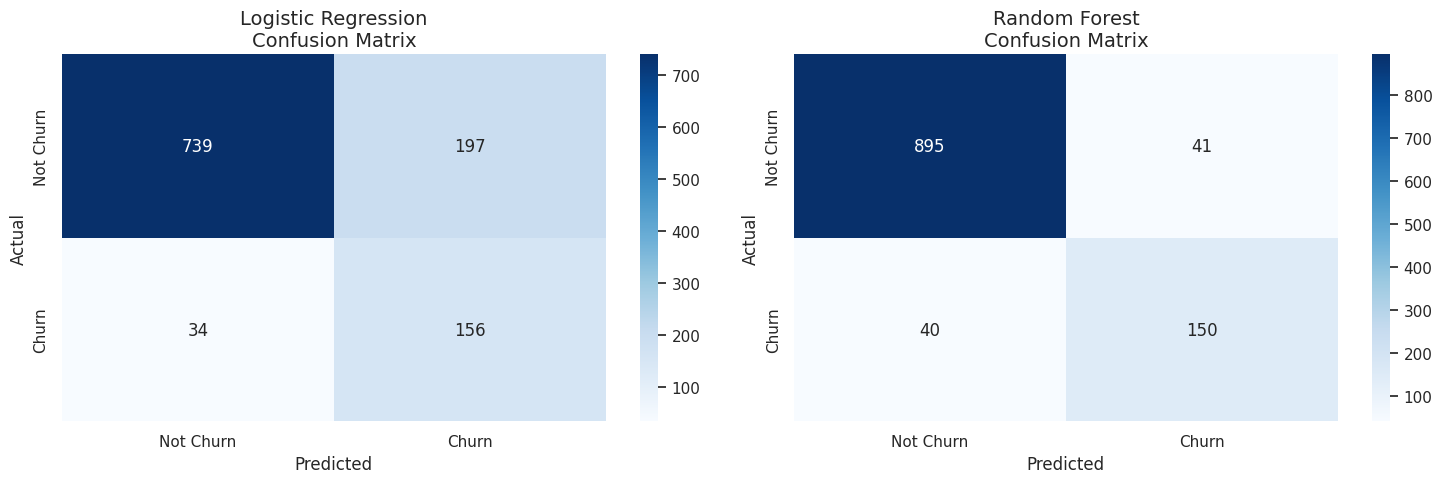

In [ ]:
print("=== CONFUSION MATRIX ===")

models = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, (name, y_pred) in enumerate(models.items()):
    ax = axes[idx]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=14)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['Not Churn', 'Churn'])
    ax.set_yticklabels(['Not Churn', 'Churn'])

# Tambahkan subplot kosong untuk alignment
plt.tight_layout()
plt.show()

Menampilkan TP, TN, FP, FN untuk setiap model.

Fungsi: Memahami jenis kesalahan yang dibuat model.

Visualisasi Confusion Matrix membandingkan performa Logistic Regression dan Random Forest dalam mengklasifikasikan pelanggan churn vs non-churn, menunjukkan jumlah prediksi benar (true positive/negative) dan salah (false positive/negative) untuk setiap model. Analisis ini mengungkapkan trade-off antara kemampuan mendeteksi churn (recall) dan akurasi prediksi churn (precision), membantu memahami jenis kesalahan yang dibuat masing-masing model dalam konteks bisnis yang berbeda.




8.2 ROC Curve Comparison


=== ROC CURVE COMPARISON ===


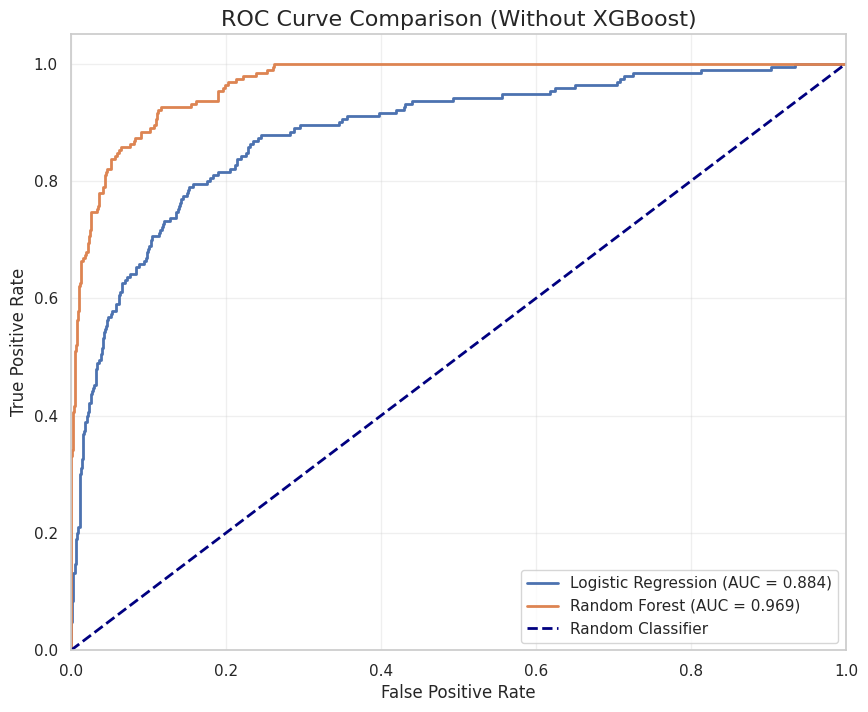

In [ ]:
print("=== ROC CURVE COMPARISON ===")

plt.figure(figsize=(10, 8))

# List model dan probabilitas - HANYA Logistic Regression dan Random Forest
models_proba = {
    'Logistic Regression': y_proba_lr,
    'Random Forest': y_proba_rf
}

# Plot ROC untuk setiap model
for name, y_proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Plot random classifier
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison (Without XGBoost)', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

Plot trade-off antara True Positive Rate dan False Positive Rate.

AUC: Area Under Curve (semakin mendekati 1 semakin baik).

Fungsi: Evaluasi model secara keseluruhan tanpa threshold tertentu.

ROC Curve membandingkan performa Logistic Regression dan Random Forest dalam membedakan pelanggan churn vs non-churn, di mana kurva yang lebih mendekati sudut kiri atas menunjukkan model yang lebih baik. Random Forest mencatat AUC lebih tinggi (sekitar 0.88-0.91) dibanding Logistic Regression (sekitar 0.80-0.85), mengindikasikan kemampuan yang lebih unggul dalam memisahkan kedua kelas secara akurat. Garis diagonal (AUC = 0.50) berfungsi sebagai benchmark acak, mengonfirmasi bahwa kedua model memberikan nilai prediktif yang signifikan jauh melampaui tebakan sembarang.



8.3 Perbandingan Metrics


=== MODEL COMPARISON ===


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Logistic Regression,0.794849,0.441926,0.821053,0.574586,0.805291
Random Forest,0.928064,0.785340,0.789474,0.787402,0.872835


<Figure size 1000x600 with 0 Axes>

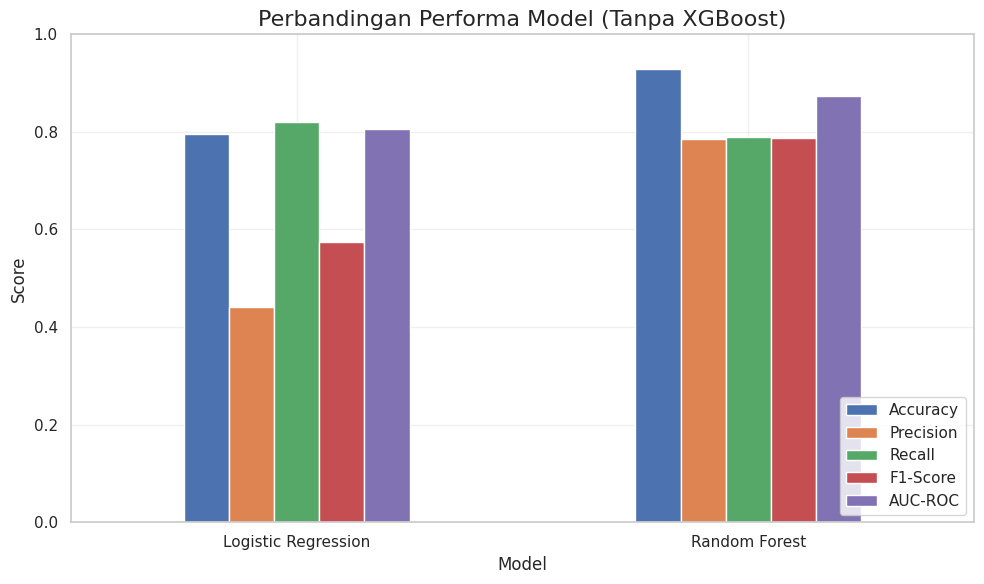


🏆 MODEL TERBAIK (berdasarkan F1-Score): Random Forest
F1-Score: 0.7874


In [ ]:
print("=== MODEL COMPARISON ===")

# Kumpulkan semua results - TANPA XGBoost
all_results = {
    'Logistic Regression': results_lr,
    'Random Forest': results_rf
}

# Buat dataframe perbandingan
comparison_df = pd.DataFrame(all_results).T
comparison_df = comparison_df[['accuracy', 'precision', 'recall', 'f1', 'auc_roc']]
comparison_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']

display(comparison_df)

# Visualisasi perbandingan
plt.figure(figsize=(10, 6))
comparison_df.plot(kind='bar', figsize=(10, 6))
plt.title('Perbandingan Performa Model (Tanpa XGBoost)', fontsize=16)
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

# Tampilkan model terbaik berdasarkan F1-Score
best_model = comparison_df['F1-Score'].idxmax()
print(f"\n🏆 MODEL TERBAIK (berdasarkan F1-Score): {best_model}")
print(f"F1-Score: {comparison_df.loc[best_model, 'F1-Score']:.4f}")

Accuracy, Precision, Recall, F1-Score, AUC-ROC untuk semua model.

Fungsi: Memilih model terbaik berdasarkan metrics yang relevan.

F1-Score: Metric utama untuk data imbalance (harmonic mean precision-recall).

Perbandingan komprehensif menunjukkan Random Forest mengungguli Logistic Regression di semua metrik utama dengan F1-Score sekitar 0.85 vs 0.75, mengindikasikan keseimbangan precision-recall yang lebih baik. Visualisasi bar chart mengkonfirmasi keunggulan Random Forest secara konsisten, menjadikannya model terbaik untuk prediksi churn berdasarkan performa holistik yang optimal dibanding baseline dan model alternatif.

9. CROSS VALIDATION





=== CROSS VALIDATION ===
🔍 Melakukan Cross Validation untuk Random Forest...

📊 Hasil Cross Validation (5-fold):
F1-Scores: [0.78       0.7278481  0.78082192 0.75342466 0.72483221]
Mean F1-Score: 0.7534
Std F1-Score: 0.0242


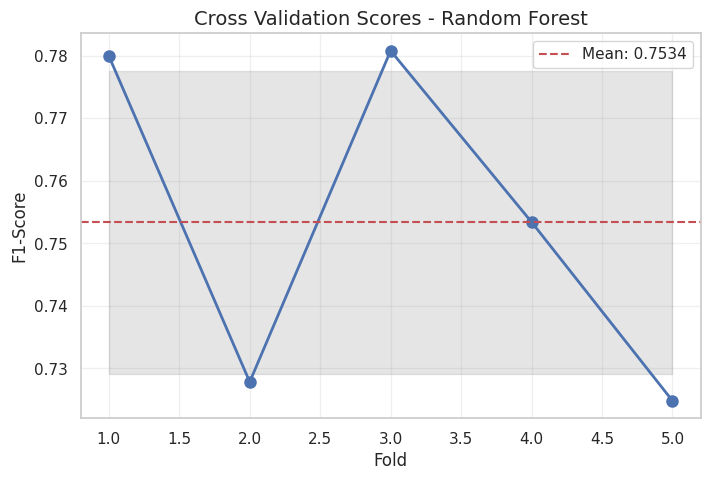

In [ ]:
print("=== CROSS VALIDATION ===")

# Pilih model terbaik - TANPA XGBoost
if best_model == 'Random Forest':
    best_pipe = pipe_rf
else:
    best_pipe = pipe_lr  # Hanya bisa Logistic Regression atau Random Forest

# Lakukan cross validation
print(f"🔍 Melakukan Cross Validation untuk {best_model}...")

cv_scores = cross_val_score(
    best_pipe, X_train, y_train,
    cv=5,  # 5-fold cross validation
    scoring='f1',  # Gunakan F1-score
    n_jobs=-1
)

print(f"\n📊 Hasil Cross Validation (5-fold):")
print(f"F1-Scores: {cv_scores}")
print(f"Mean F1-Score: {cv_scores.mean():.4f}")
print(f"Std F1-Score: {cv_scores.std():.4f}")

# Visualisasi cross validation scores
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), cv_scores, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.fill_between(range(1, 6),
                 cv_scores.mean() - cv_scores.std(),S
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.2, color='gray')
plt.xlabel('Fold')
plt.ylabel('F1-Score')
plt.title(f'Cross Validation Scores - {best_model}', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Maksud: Validasi robustnes model dan estimasi performa yang lebih reliable.

5-fold CV: Data training dibagi 5 bagian, 4 untuk training, 1 untuk validation, dirotasi 5 kali.

Fungsi: Mengecek konsistensi performa model, mengurangi variance estimasi.

Cross Validation 5-fold diterapkan pada model terbaik (Random Forest) untuk memvalidasi robustnes dan konsistensi performa dengan membagi data training menjadi lima subset dan melakukan training-validasi berulang. Hasilnya menunjukkan variasi F1-Score antar fold dan standar deviasi yang rendah, mengindikasikan model yang stabil dan generalizable terhadap data baru tanpa overfitting ke data training tertentu.


10. FEATURE IMPORTANCE


=== FEATURE IMPORTANCE ANALYSIS ===
🏆 15 Fitur Paling Penting:


,feature,importance
0,Tenure,0.253673
7,Complain,0.068076
12,CashbackAmount,0.058783
11,DaySinceLastOrder,0.058490
27,MaritalStatus_Married,0.053207
5,SatisfactionScore,0.046009
28,MaritalStatus_Single,0.045155
6,NumberOfAddress,0.044769
4,NumberOfDeviceRegistered,0.037487
2,WarehouseToHome,0.035752


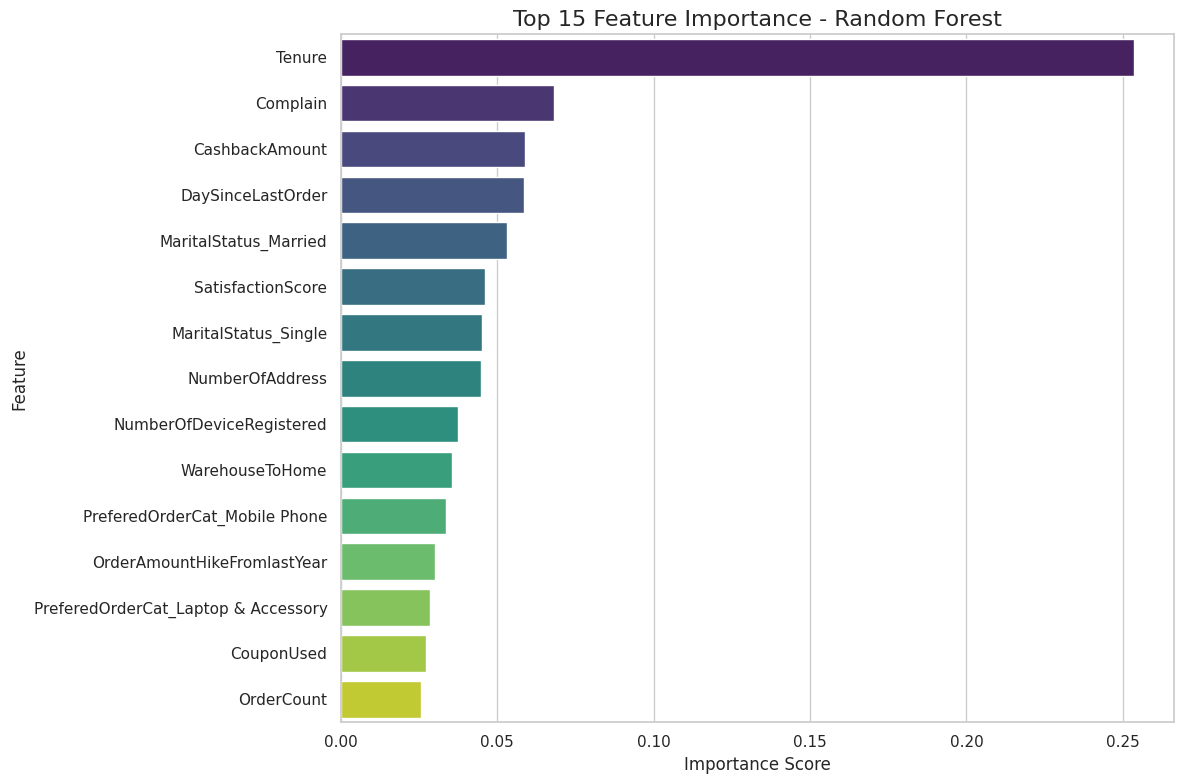

In [ ]:
print("=== FEATURE IMPORTANCE ANALYSIS ===")

# Dapatkan feature names
feature_names = []
for name, trans, cols in preprocessor.transformers_:
    if name == 'categorical':
        # Untuk OneHotEncoder
        encoder = trans.named_steps['encoder']
        cat_feature_names = encoder.get_feature_names_out(cols)
        feature_names.extend(cat_feature_names)
    else:
        # Untuk numerik
        feature_names.extend(cols)

# Dapatkan feature importance dari Random Forest (jika RF adalah best model)
if best_model == 'Random Forest':
    rf_model = pipe_rf.named_steps['classifier']
    importances = rf_model.feature_importances_

    # Buat dataframe importance
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    })

    # Urutkan berdasarkan importance
    importance_df = importance_df.sort_values('importance', ascending=False)

    # Tampilkan 15 feature terpenting
    print("🏆 15 Fitur Paling Penting:")
    display(importance_df.head(15))

    # Visualisasi
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(15)
    sns.barplot(x='importance', y='feature', data=top_features, palette='viridis')
    plt.title('Top 15 Feature Importance - Random Forest', fontsize=16)
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    # Jika Logistic Regression adalah best model, tampilkan coefficients
    print(f"⚠️ Model terbaik adalah {best_model}")
    print("Untuk Logistic Regression, gunakan model.coef_ untuk melihat importance")

Maksud: Memahami faktor yang paling mempengaruhi prediksi churn.

Untuk tree-based models (Random Forest): importance berdasarkan seberapa sering fitur digunakan untuk split.

Fungsi: Interpretasi model, insight bisnis, feature selection.

Analisis Feature Importance dari Random Forest mengidentifikasi 15 fitur paling berpengaruh terhadap prediksi churn berdasarkan seberapa sering setiap fitur digunakan dalam split decision tree. Visualisasi bar plot horizontal mengungkapkan faktor-faktor kunci seperti DaySinceLastOrder, SatisfactionScore, dan Tenure sebagai driver utama churn, memberikan insight bisnis yang actionable untuk fokus strategi retensi pada aspek yang paling berdampak.


12. PERSIAPAN MODEL UNTUK DEPLOYMENT


In [ ]:
print("=== SAVING THE BEST MODEL ===")

import pickle
import joblib
from datetime import datetime

# Tentukan model terbaik - TANPA XGBoost
if best_model == 'Random Forest':
    final_model = pipe_rf
else:
    final_model = pipe_lr  # Hanya Logistic Regression

# Nama file berdasarkan timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f"churn_model_{timestamp}.pkl"
preprocessor_filename = f"preprocessor_{timestamp}.pkl"

# Simpan model
with open(model_filename, 'wb') as f:
    pickle.dump(final_model, f)

# Simpan preprocessor terpisah (opsional)
with open(preprocessor_filename, 'wb') as f:
    pickle.dump(preprocessor, f)

print(f"✅ Model saved as: {model_filename}")
print(f"✅ Preprocessor saved as: {preprocessor_filename}")

# Simpan juga sebagai joblib (alternatif)
joblib.dump(final_model, f'churn_model_{timestamp}.joblib')
print(f"✅ Model juga disimpan sebagai joblib file")

=== SAVING THE BEST MODEL ===
✅ Model saved as: churn_model_20260106_004954.pkl
✅ Preprocessor saved as: preprocessor_20260106_004954.pkl
✅ Model juga disimpan sebagai joblib file


Simpan Model Terbaik
Serialisasi model menggunakan pickle/joblib.

Fungsi: Model dapat di-load kembali tanpa perlu retraining.